<a href="https://colab.research.google.com/github/richab2005/MachineLearning-/blob/main/Assi4KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data= pd.read_excel('/content/drive/My Drive/ML/Iris.xlsx')
data

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [ ]:
# Step 3: Figure out Dependent feature (y) and Independent features (X)
X = data[['Petal_Length', 'Petal_Width']]
y = data['Class']


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 4: Perform Label Encoding on the target feature (y)
le = LabelEncoder()
y = le.fit_transform(y)
print("\nEncoded classes:", list(le.classes_))
print("Encoded target sample:", y[:10])
y


Encoded classes: ['Setosa', 'Versicolor', 'Virginica']
Encoded target sample: [0 0 0 0 0 0 0 0 0 0]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from matplotlib.colors import ListedColormap

In [ ]:
# Step 5: Split the dataset into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:

# Step 6: Perform Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Step 7: Apply cross validation to choose the best value of k
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
cv_scores

[np.float64(0.9619047619047618),
 np.float64(0.9714285714285713),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381),
 np.float64(0.980952380952381)]

In [ ]:
# Step 8: Print all the values of k along with the accuracy
print("\nK values and corresponding accuracy:")
for k, acc in zip(k_values, cv_scores):
    print(f"k = {k} → Accuracy = {acc:.4f}")


K values and corresponding accuracy:
k = 1 → Accuracy = 0.9619
k = 2 → Accuracy = 0.9714
k = 3 → Accuracy = 0.9810
k = 4 → Accuracy = 0.9810
k = 5 → Accuracy = 0.9810
k = 6 → Accuracy = 0.9810
k = 7 → Accuracy = 0.9810
k = 8 → Accuracy = 0.9810
k = 9 → Accuracy = 0.9810
k = 10 → Accuracy = 0.9810
k = 11 → Accuracy = 0.9810
k = 12 → Accuracy = 0.9810
k = 13 → Accuracy = 0.9810
k = 14 → Accuracy = 0.9810
k = 15 → Accuracy = 0.9810
k = 16 → Accuracy = 0.9810
k = 17 → Accuracy = 0.9810
k = 18 → Accuracy = 0.9810
k = 19 → Accuracy = 0.9810
k = 20 → Accuracy = 0.9810


In [ ]:
# Step 9: Determine the best value of k
best_k = k_values[np.argmax(cv_scores)]
print(f"\n✅ Best value of k: {best_k}")



✅ Best value of k: 3


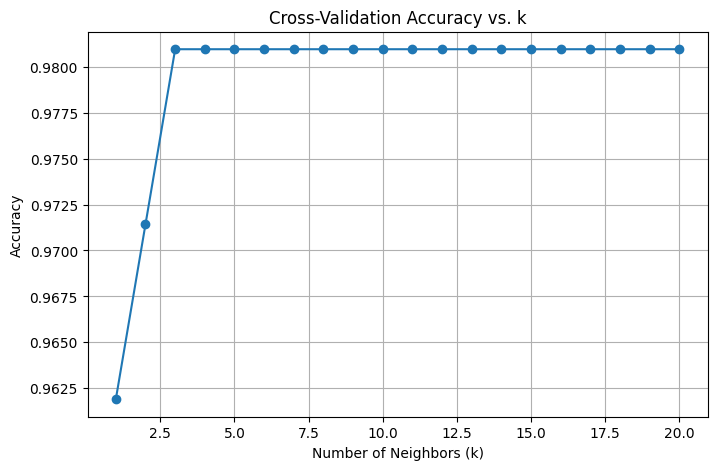

In [ ]:
# Step 10: Plot cross-validation accuracy vs. k
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.title('Cross-Validation Accuracy vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Step 11: Retrain KNN with best k on full training set
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)



KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Step 12: Predict on test set
y_pred = knn.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))


Test Accuracy: 0.9333333333333333


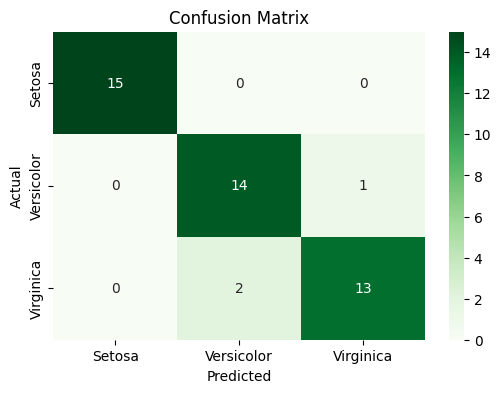

In [ ]:
# Step 13: Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import  numpy as np
# Step 14: Print the Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



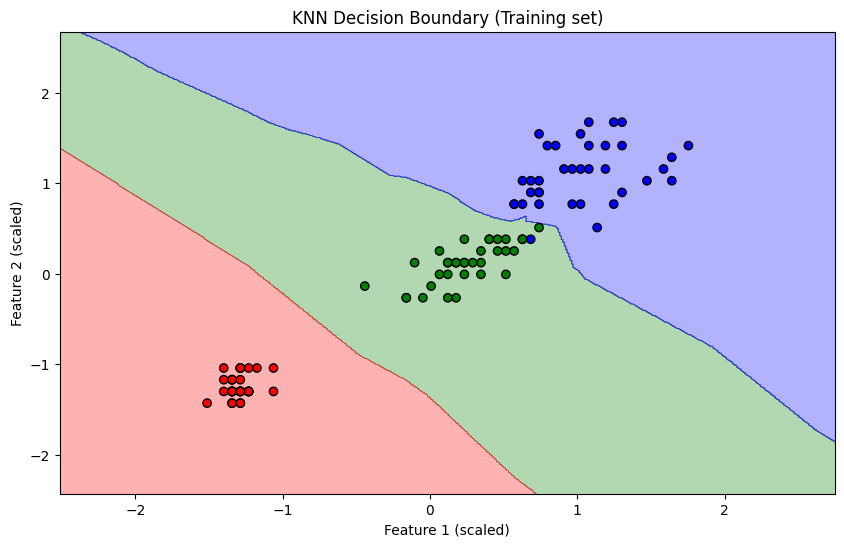

In [ ]:
# Step 15: Plot the decision regions (on training set + test overlay)
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=0.01),
    np.arange(start=X_set[:, 1].min()-1, stop=X_set[:, 1].max()+1, step=0.01)
)
plt.figure(figsize=(10,6))
plt.contourf(X1, X2, knn.predict(np.array([X1.ravel(), X2.ravel()]).T)[:, np.newaxis]
             .reshape(X1.shape), alpha=0.3, cmap=ListedColormap(('red', 'green', 'blue')))
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap=ListedColormap(('red', 'green', 'blue')))
plt.title('KNN Decision Boundary (Training set)')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.show()